In [1]:
# Add the root path of the pyqula library
import os ; import sys
try: sys.path.append(os.environ["PYQULAROOT"]) # add the library via environmental variable
except: 
    try: from pyqula import geometry # check if the library is present
    except: #print("Install pyqula with\npip install --upgrade pyqula") # pyqula must be installed
        print("pyqula needs to be installed, installing it")
        import subprocess ; subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade","pyqula"])

# some default parameters in matplotlib
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [20, 8]
plt.rcParams['font.size'] = 22
plt.rcParams['image.cmap'] = 'coolwarm'


import numpy as np

# Advanced Quantum Materials, session 3: Topological band structure theory
In this session we will address several examples of topological states of matter, including Quantum Hall insulators and quantum spin Hall insulators

### Contents
- The quantum Hall effect and its edge states
- Chern insulators and edge states
- Bulk topological invarians and the Chern number
- Quantum spin Hall insulators
- Quantum Valley Hall insulators

### Learning outcomes
- Identify chiral edge states in electronic structures and its topological origin
- Rationalize topological states in terms of bulk invariants

### About the exercises
The notebooks contain two types of exercises, with each exercise containing **Quiz** questions to answer
- ***Core***: basic exercises you should understand in each session
- ***Challenge***: advanced exercises to dive deeper into concepts, not necessary to understand in full in each session

## From electrons in a ribbon to the quantum Hall state (***Core***)
We will show how edge states and flat abnds appear when including a magnetic field

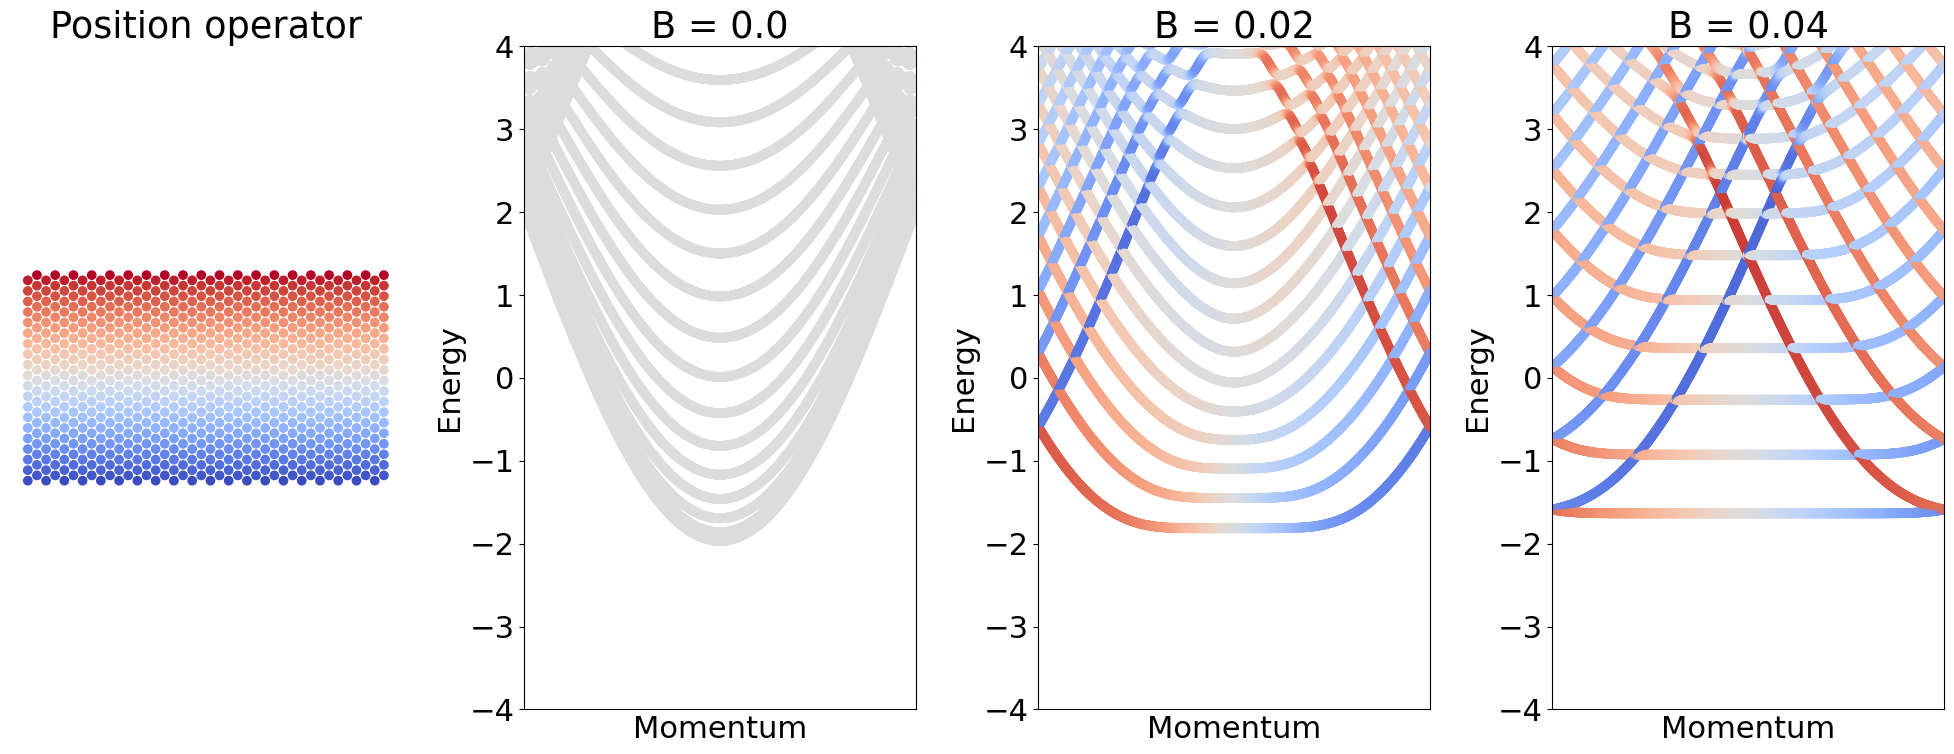

In [2]:
from pyqula import geometry
N = 20 # number of unit cells as the width
g = geometry.triangular_ribbon(N) # triangular lattice
Bs = [0.,0.02,0.04] # magnetic field (measured in units of magnetic flux)

# draw a ribbon with the position operator
gs = g.get_supercell(20) 
plt.subplot(1,len(Bs)+1,1) ; plt.title("Position operator")
plt.scatter(gs.r[:,0],gs.r[:,1],c=gs.r[:,1]) ; plt.axis("equal") ; plt.axis("off")

ii = 0
for B in Bs:
    h = g.get_hamiltonian(tij=[-1]) ; h.add_onsite(4.) # generate the Hamiltonian
    h.add_orbital_magnetic_field(B) # add an out-of plane magnetic field
    # plot the bands
    plt.subplot(1,len(Bs)+1,ii+2) ; plt.title("B = "+str(B)) ; ii += 1 # create subplot and increase counter
    (k,e,c) = h.get_bands(kpath=["X","G","X"],operator="yposition") # compute band structure
    plt.scatter(k,e,c=c,vmin=-N/2,vmax=N/2) ; plt.xlabel("Momentum") ; plt.ylabel("Energy") ; plt.xticks([]) 
    plt.ylim([-4.,4.]) ;  plt.xlim([min(k),max(k)])
    
plt.tight_layout()

### Exercise
- In plot on the right, what are the blue, red and grey states?
- In which direction do blue states propagate at negative energies?
- In which direction do red states propagate at negative energies?

## The quantum Hall effect in graphene (***Core***)
We will now show the emergence of edge states for a 2d electron gas with a magnetic field

(0.0, 400.0)

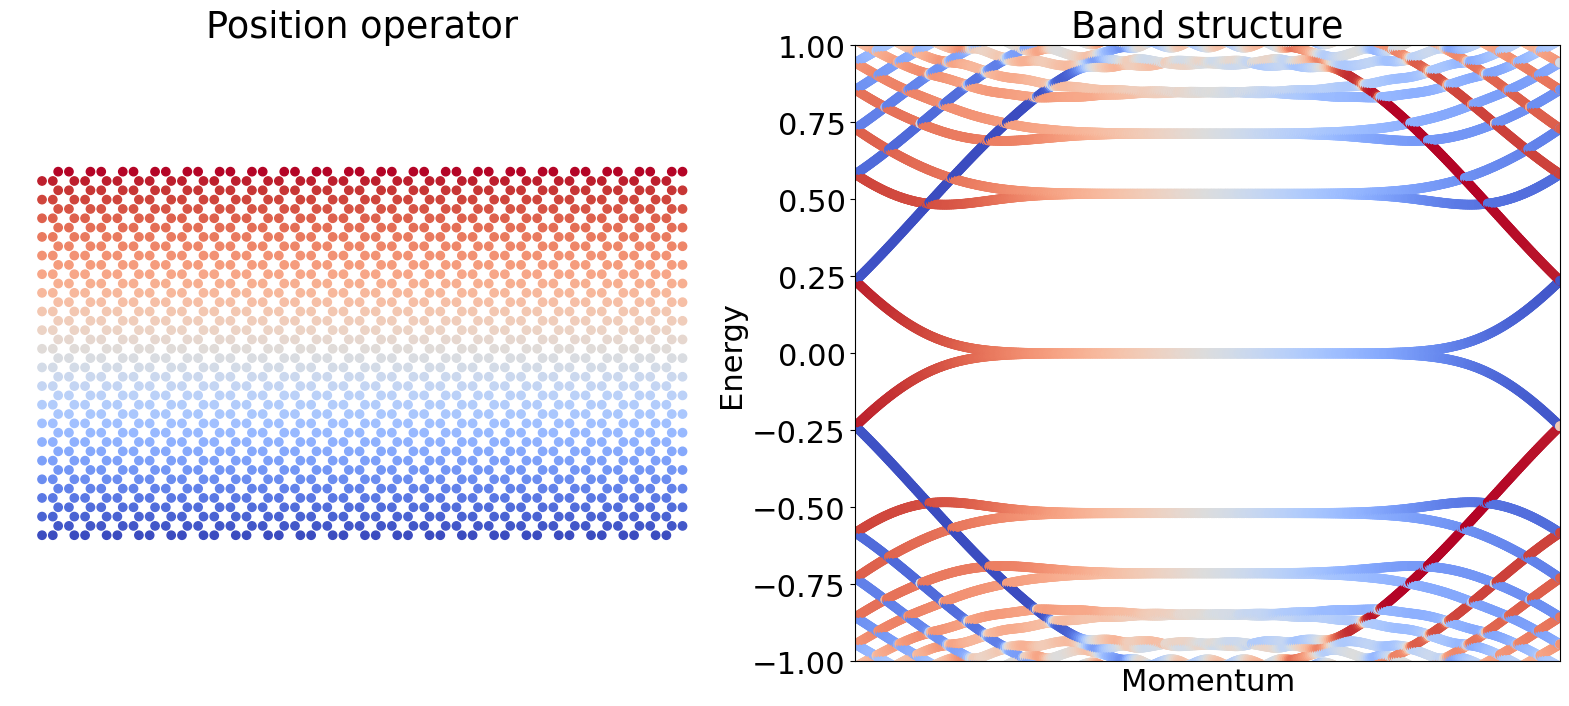

In [3]:
from pyqula import geometry
g = geometry.honeycomb_armchair_ribbon(20) # honeycomb ribbon with armchair edge, the number controls the width
h = g.get_hamiltonian() # generate the Hamiltonian
h.add_orbital_magnetic_field(0.01) # add an out-of plane magnetic field

# draw a ribbon with the position operator
gs = g.get_supercell(20) 
plt.subplot(1,2,1) ; plt.title("Position operator")
plt.scatter(gs.r[:,0],gs.r[:,1],c=gs.r[:,1]) ; plt.axis("equal") ; plt.axis("off")

# plot the bands
plt.subplot(1,2,2) ; plt.title("Band structure")
(k,e,c) = h.get_bands(kpath=["X","G","X"],operator="yposition") # compute band structure
plt.scatter(k,e,c=c) ; plt.xlabel("Momentum") ; plt.ylabel("Energy") ; plt.xticks([]) 
plt.ylim([-1.,1.]) ;  plt.xlim([min(k),max(k)])

### Exercise
- Remove the magnetic field, do you still see states localized at the edges?
- Replace the honeycomb ribbon by a zigzag ribbon (honeycomb_zizgag_ribbon). How does the spectra look like?
- Make the ribbon wider, which change do you see in the band structure?
- Replace the honeycomb lattice by a square lattice. Do you observe Landau levels?

#### In the lab
- The quantum Hall state in graphene appears even at room temperature
https://www.science.org/doi/10.1126/science.1137201

## Localization of the edge states in the quantum Hall effect (***Challenge***)
Let us now look at where the states are localized as function of energy

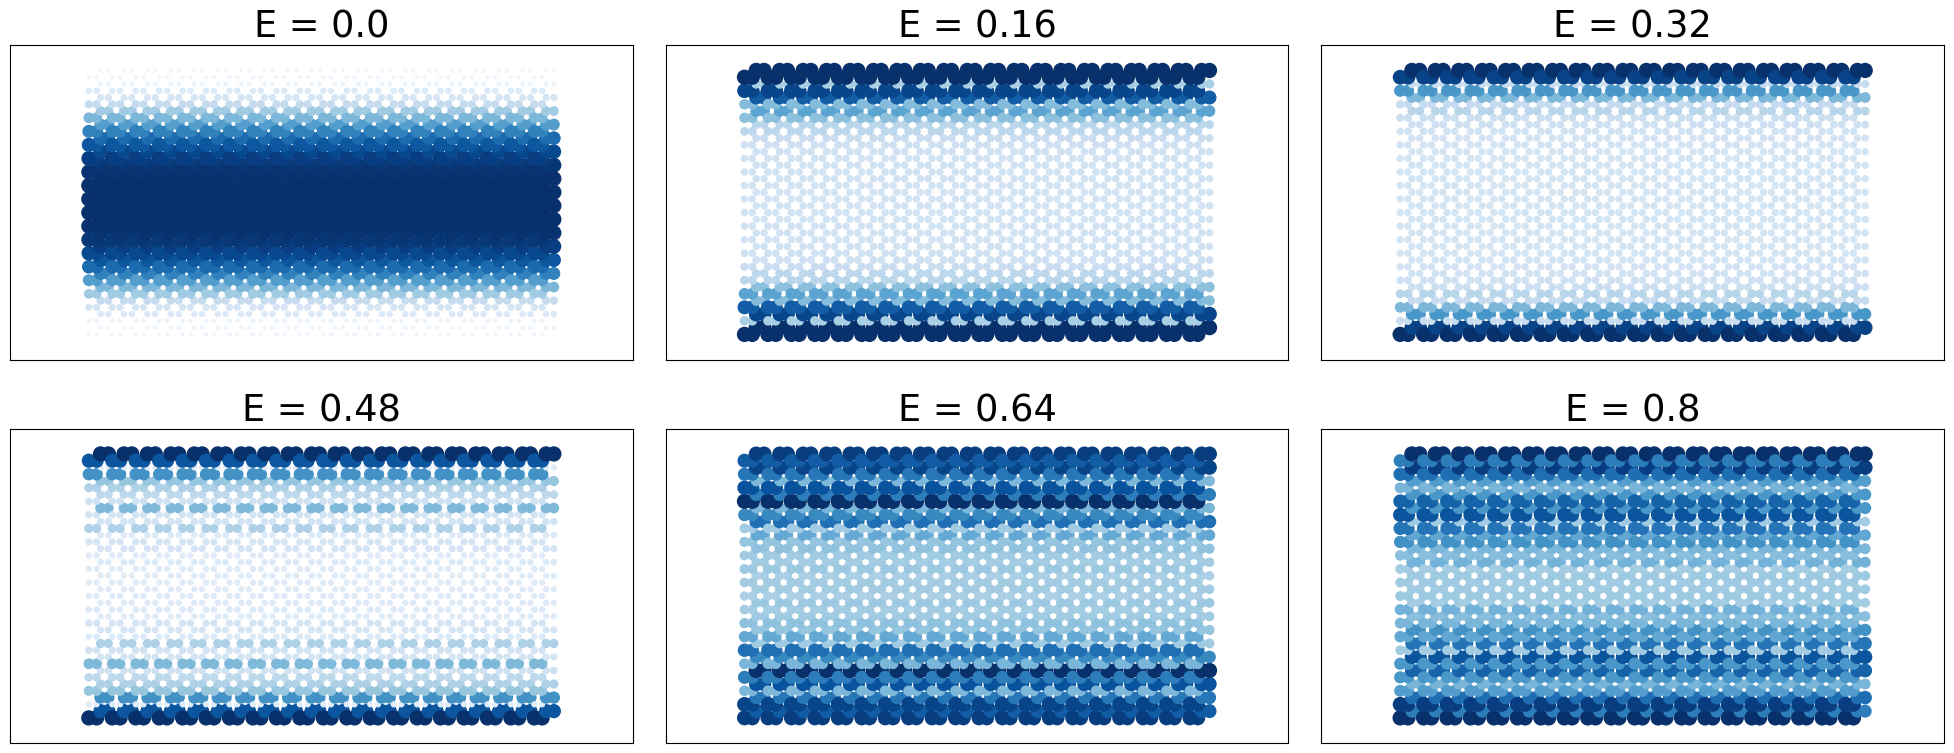

In [4]:
from pyqula import geometry
N = 6 # number of plots
ws = np.linspace(0.,0.8,N) # energies

g = geometry.honeycomb_armchair_ribbon(20) # honeycomb ribbon with armchair edge, the number controls the width
h = g.get_hamiltonian() # generate the Hamiltonian
h.add_orbital_magnetic_field(0.01) # add an out-of plane magnetic field

ii = 1 # counter for the subplots
for w in ws:
    plt.subplot(N//3,3,ii); ii += 1 
    (x,y,d) = h.get_ldos(e=w,nrep=20,delta=1e-2,nk=20) # compute local density of states
    plt.title("E = "+str(np.round(w,2))) # set the title
    plt.scatter(x,y,c=d,s=d/np.max(d)*100,vmin=0.,cmap="Blues") ; plt.yticks([]) ; plt.xticks([]) ; plt.axis("equal")# plot
plt.tight_layout() # adjust the subplots

### Exercise
- Recompute the previous local density of states, but now with a smaller magnetic field. What happens to the edge states?
- Recompute the previous local density of states, but now with a narrower ribbon. What happens to the edge states?

## The quantum anomalous Hall effect (***Core***)
Before we considered a system with a magnetic field that has topological edge states. We will now see that topological edge states can appear in the absence of an external magnetic field

(-1.0, 1.0)

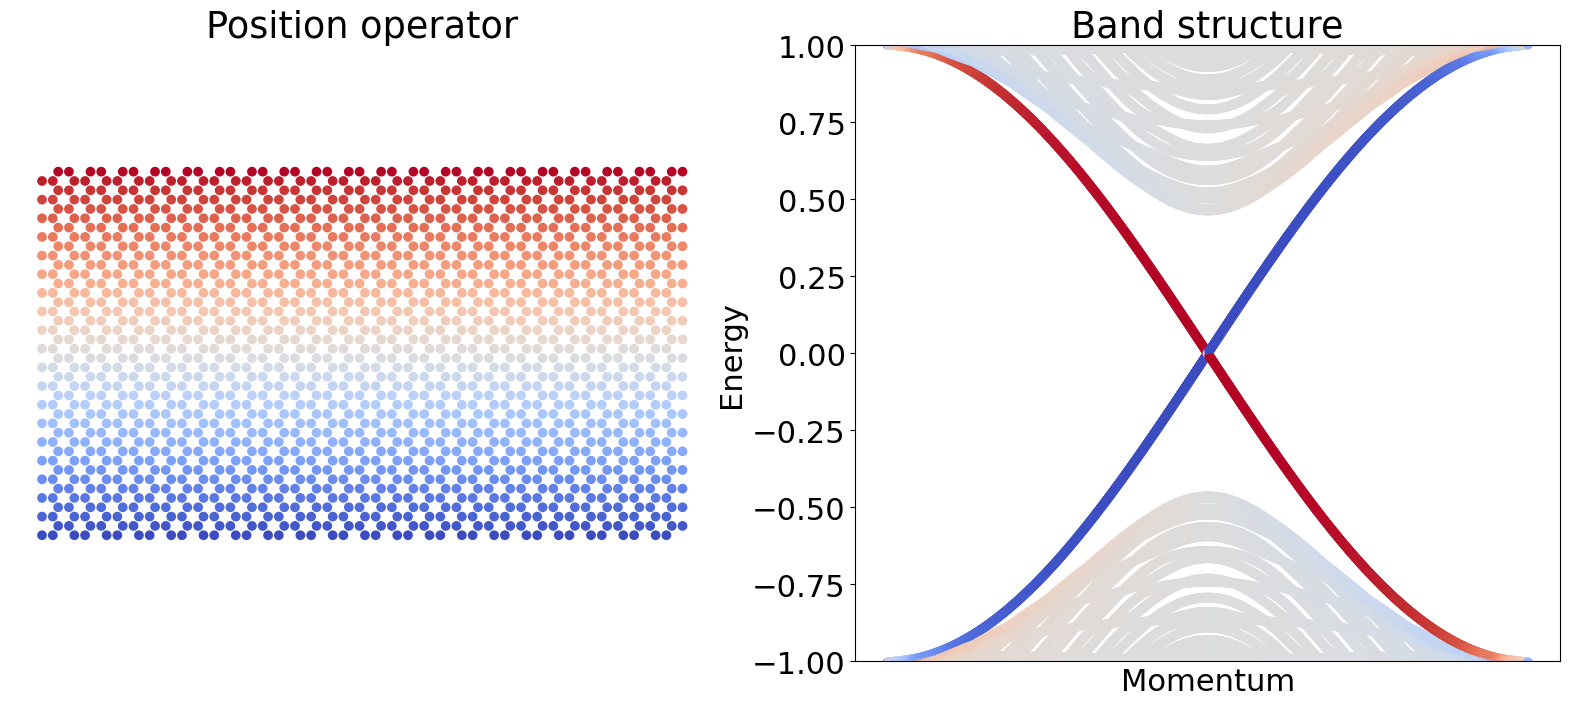

In [5]:
from pyqula import geometry
g = geometry.honeycomb_armchair_ribbon(20) # honeycomb ribbon with armchair edge, the number controls the width
h = g.get_hamiltonian() # generate the Hamiltonian
h.add_haldane(0.1) # add Haldane coupling (second neighbor imaginary hopping)

# draw a ribbon with the position operator
gs = g.get_supercell(20) 
plt.subplot(1,2,1) ; plt.title("Position operator")
plt.scatter(gs.r[:,0],gs.r[:,1],c=gs.r[:,1]) ; plt.axis("equal") ; plt.axis("off")

# plot the bands
plt.subplot(1,2,2) ; plt.title("Band structure")
(k,e,c) = h.get_bands(kpath=["X","G","X"],operator="yposition") # compute band structure
plt.scatter(k,e,c=c) ; plt.xlabel("Momentum") ; plt.ylabel("Energy") ; plt.xticks([]) ; plt.ylim([-1.,1.])# plot

### Exercise
- Make the ribbon narrower. What happens to the edge states, and why?
- Replace the honeycomb ribbon by a zigzag ribbon (honeycomb_zigzag_ribbon). How does the spectra look like?


## Edge states of the quantum anomalous Hall state (***Core***)
Let us now look at the local density of states in a ribbon as function of the energy

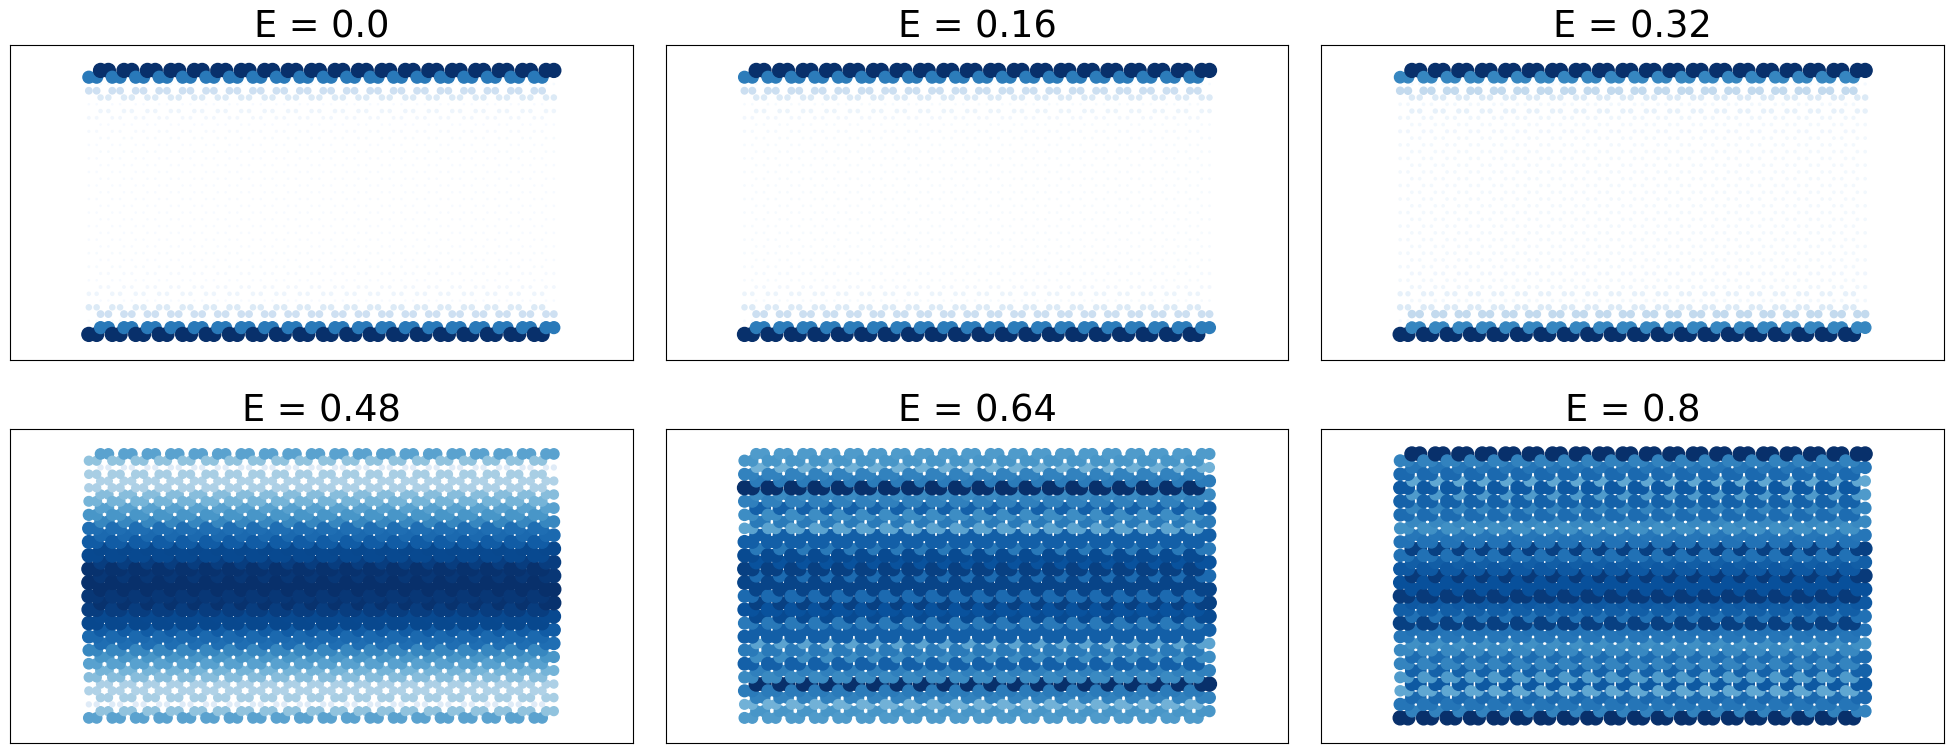

In [6]:
from pyqula import geometry
N = 6 # number of plots
ws = np.linspace(0.,0.8,N) # energies

g = geometry.honeycomb_armchair_ribbon(20) # honeycomb ribbon with armchair edge, the number controls the width
h = g.get_hamiltonian() # generate the Hamiltonian
h.add_haldane(0.1) # add Haldane coupling (seocnd neighbor imaginary hopping)

ii = 1 # counter for the subplots
for w in ws:
    plt.subplot(N//3,3,ii); ii += 1 
    (x,y,d) = h.get_ldos(e=w,nrep=20,delta=1e-2,nk=20) # compute local density of states
    plt.title("E = "+str(np.round(w,2))) # set the title
    plt.scatter(x,y,c=d,s=d/np.max(d)*100,vmin=0.,cmap="Blues") ; plt.yticks([]) ; plt.xticks([]) ; plt.axis("equal")# plot
plt.tight_layout() # adjust the subplots

### Exercise
- At which energies do you have edge states and at which bulk states?
- Increase the value of the Haldane coupling. At which energies you have now edge states

## Topological edge states in irregular geometries (***Challenge***)
Before we were considering systems that have translational symmetry in the x direction, showing that topological edge states appear. We will now focus on 0d systems with complex boundaries, showing that those same edge states survive

(-12.38416327411748,
 12.38416327411748,
 -14.299999999999997,
 14.299999999999997)

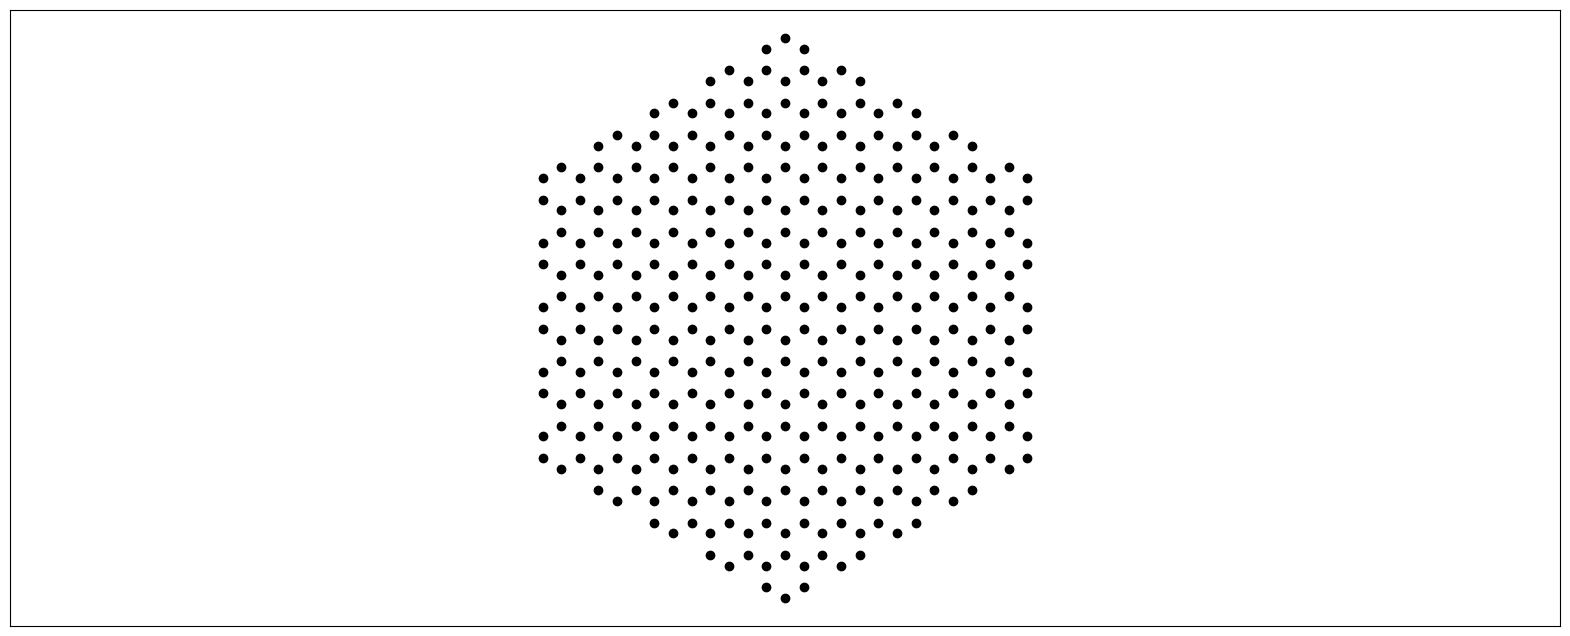

In [7]:
# let us first show a few different islands. 
# For that, we will use a special library that allows to generate geometries of islands systematically
from pyqula import islands
g = islands.get_geometry(name="honeycomb",n=8,nedges=6,rot=np.pi/6.) # get an armchair island, n controls the size
plt.scatter(g.r[:,0],g.r[:,1],c="black") ;  plt.yticks([]) ; plt.xticks([]) ; plt.axis("equal") # plot

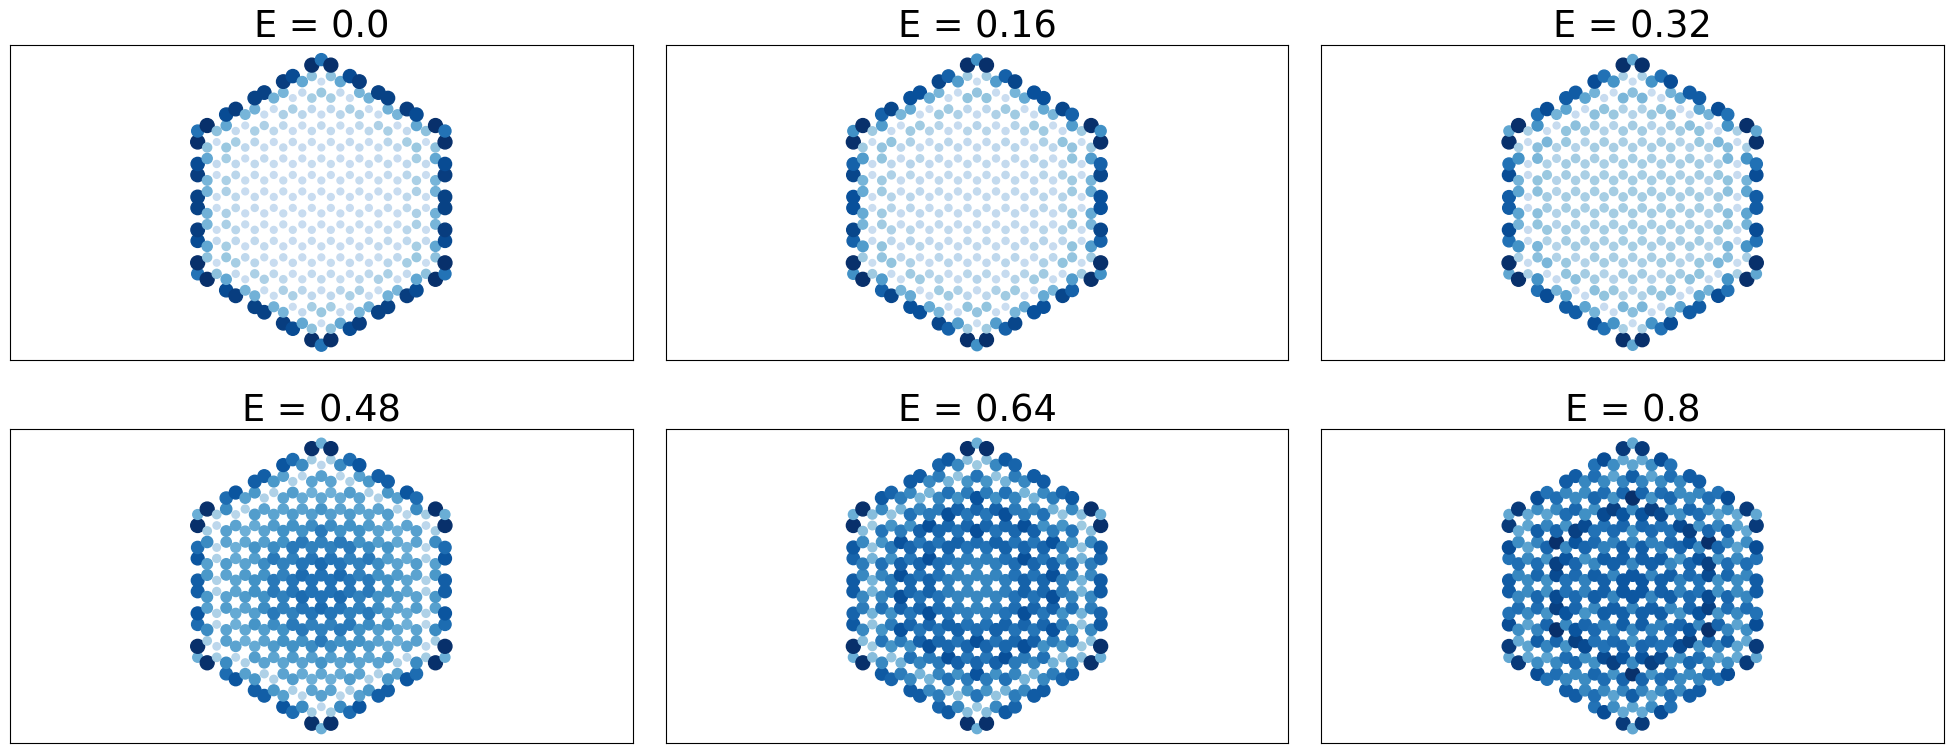

In [8]:
# let us now compute the local density of states in the presence of Haldane coupling
from pyqula import islands
g = islands.get_geometry(name="honeycomb",n=8,nedges=6,rot=np.pi/6.) # get an armchair island
h = g.get_hamiltonian(tij=[1.,0.3]) # generate the Hamiltonian, now also with 2nd neighbor hopping
h.set_filling(0.5) # put at half filling
h.add_haldane(0.1) # add Haldane coupling (seocnd neighbor imaginary hopping)

ii = 1 # counter for the subplots
for w in ws:
    plt.subplot(N//3,3,ii); ii += 1 
    (x,y,d) = h.get_ldos(e=w,nrep=20,delta=1e-1) # compute local density of states
    plt.title("E = "+str(np.round(w,2))) # set the title
    plt.scatter(x,y,c=d,s=d/np.max(d)*100,vmin=0.,cmap="Blues") ; plt.yticks([]) 
    plt.xticks([]) ; plt.axis("equal")# plot
plt.tight_layout() # adjust the subplots

### Exercise
- Make the island smaller. What happens to the edge states?
- Decrease the value of the Haldane coupling. What happens to the edge states?
- Change the number of edges of the islands (nedges). What happens to the edge states?

## Topological states and topological invariants (***Challenge***)
So far we have focused on the mergence of edge states. Let us now address the topological reason for the emergence of edge modes: the Berry curvature

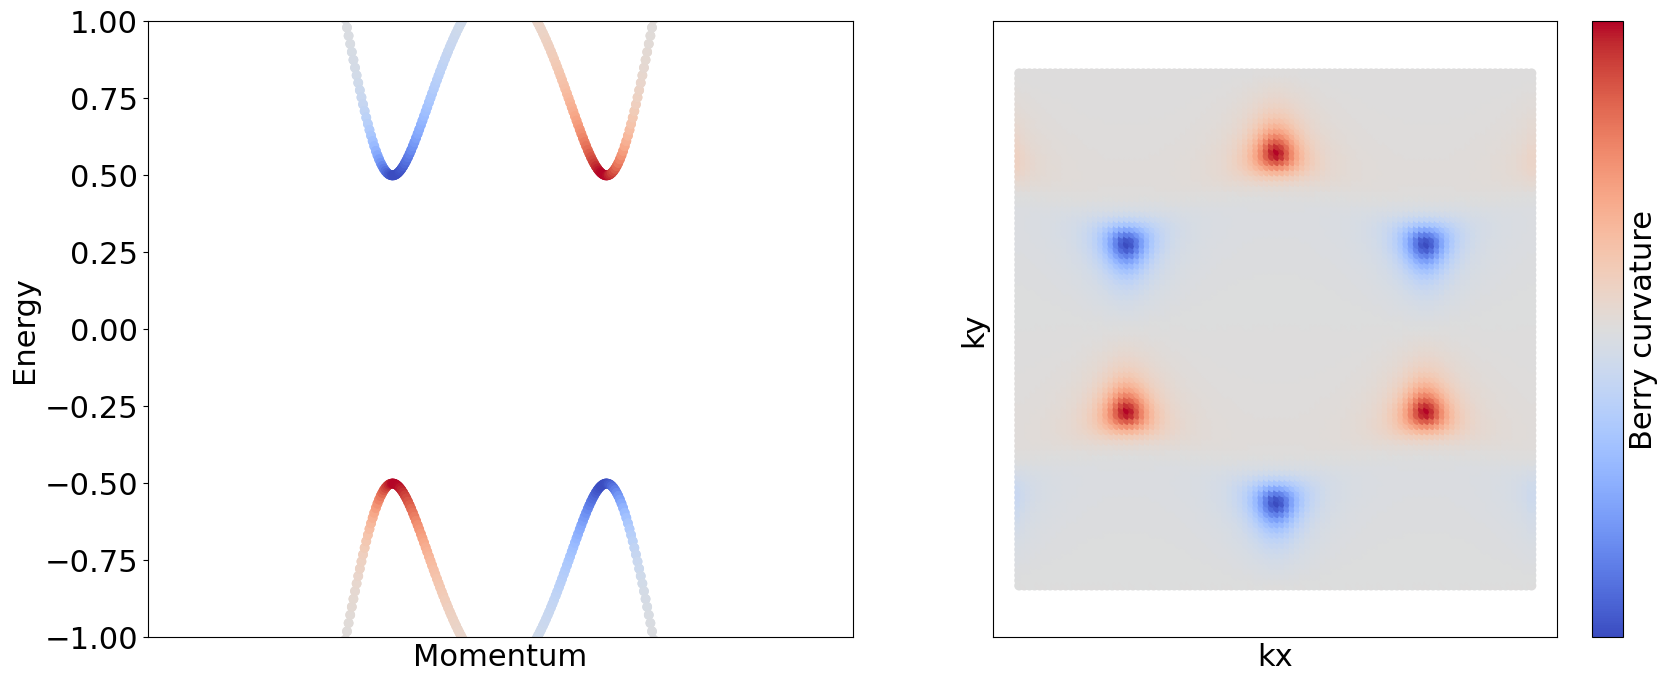

In [9]:
# Now let us do the same, but with a sublattice imbalance
from pyqula import geometry
g = geometry.honeycomb_lattice() # honeycomb lattice
h = g.get_hamiltonian() # generate the Hamiltonian
h.add_sublattice_imbalance(0.5) # add sublattice imbalance (trivial gap)

# let us first compute the band structure, highlighting the Berry curvature
plt.subplot(1,2,1)
(k,e,c) = h.get_bands(operator="Berry") # compute band structure
plt.scatter(k,e,c=c) ; plt.xlabel("Momentum") ; plt.ylabel("Energy") ; plt.xticks([]) ; plt.ylim([-1.,1.]) # plot

# and now lets compute the berry curvature in reciprocal space for the occupied bands
plt.subplot(1,2,2)
(kx,ky,be) = h.get_berry_curvature() # compute band structure
plt.scatter(kx,ky,c=-be/np.max(np.abs(be)),vmin=-1,vmax=1) # plot the Berry curvature in 2D
plt.xlabel("kx") ; plt.ylabel("ky") ; plt.axis("equal") 
plt.xticks([]) ; plt.yticks([])
plt.colorbar(label="Berry curvature",ticks=[]) 

### Exercise
- If you integrate the Berry curvature for the case of Haldane coupling, would you obtain a non-zero value?
- If you integrate the Berry curvature for the case of sublattice imbalance, would you obtain a non-zero value?
- Include simultanously a sublattice imbalance and Haldane coupling. What happens when the gap closes?

#### In the lab
- Spontaneous Chern insulators appear in twisted graphene bilayers on hBN
https://www.science.org/doi/10.1126/science.aay5533

## Topological phase transitions in the bulk (***Challenge***)
Let us now see how a topological phase transition takes place in the bulk, when a trivial gap overcomes a topological gap

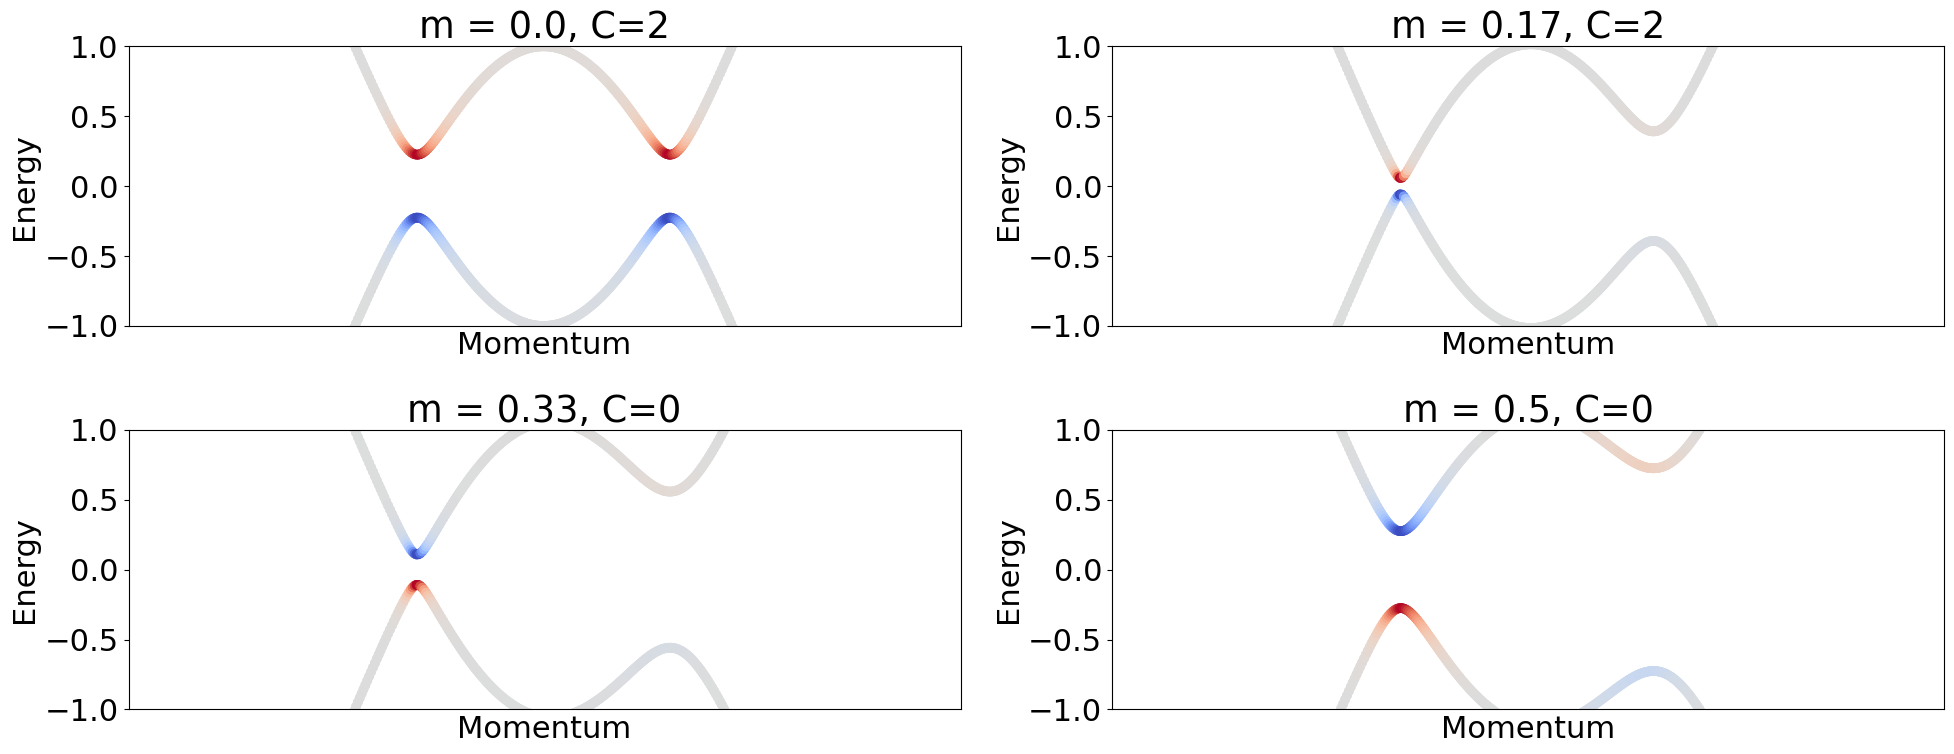

In [10]:
from pyqula import geometry
N = 4 # number of plots
ms = np.linspace(0.,0.5,N) # energies

g = geometry.honeycomb_lattice() # honeycomb ribbon with armchair edge


ii = 1 # counter for the subplots
for m in ms:
    plt.subplot(N//2,2,ii); ii += 1 
    h = g.get_hamiltonian() # generate the Hamiltonian
    h.add_haldane(0.05) # add Haldane coupling
    h.add_sublattice_imbalance(m) # add a sublattice imbalance
    (k,e,c) = h.get_bands(operator="Berry") # compute band structure
    plt.scatter(k,e,c=c) ; plt.xlabel("Momentum") ; plt.ylabel("Energy") 
    plt.xticks([]) ; plt.ylim([-1.,1.]) # plot
    C = np.round(h.get_chern(nk=60)) # compute Chern number
    plt.title("m = "+str(np.round(m,2))+", C="+str(int(C))) # set the title
plt.tight_layout() # adjust the subplots

### Exercise
- If you double the strength of the Haldane coupling, at which value of the sublattice imbalance do you have a gap closing?

## Topological phase transitions in the edge (***Core***)
Let us now see how a topological phase transition takes place in the edge, when a trivial gap overcomes a topological gap

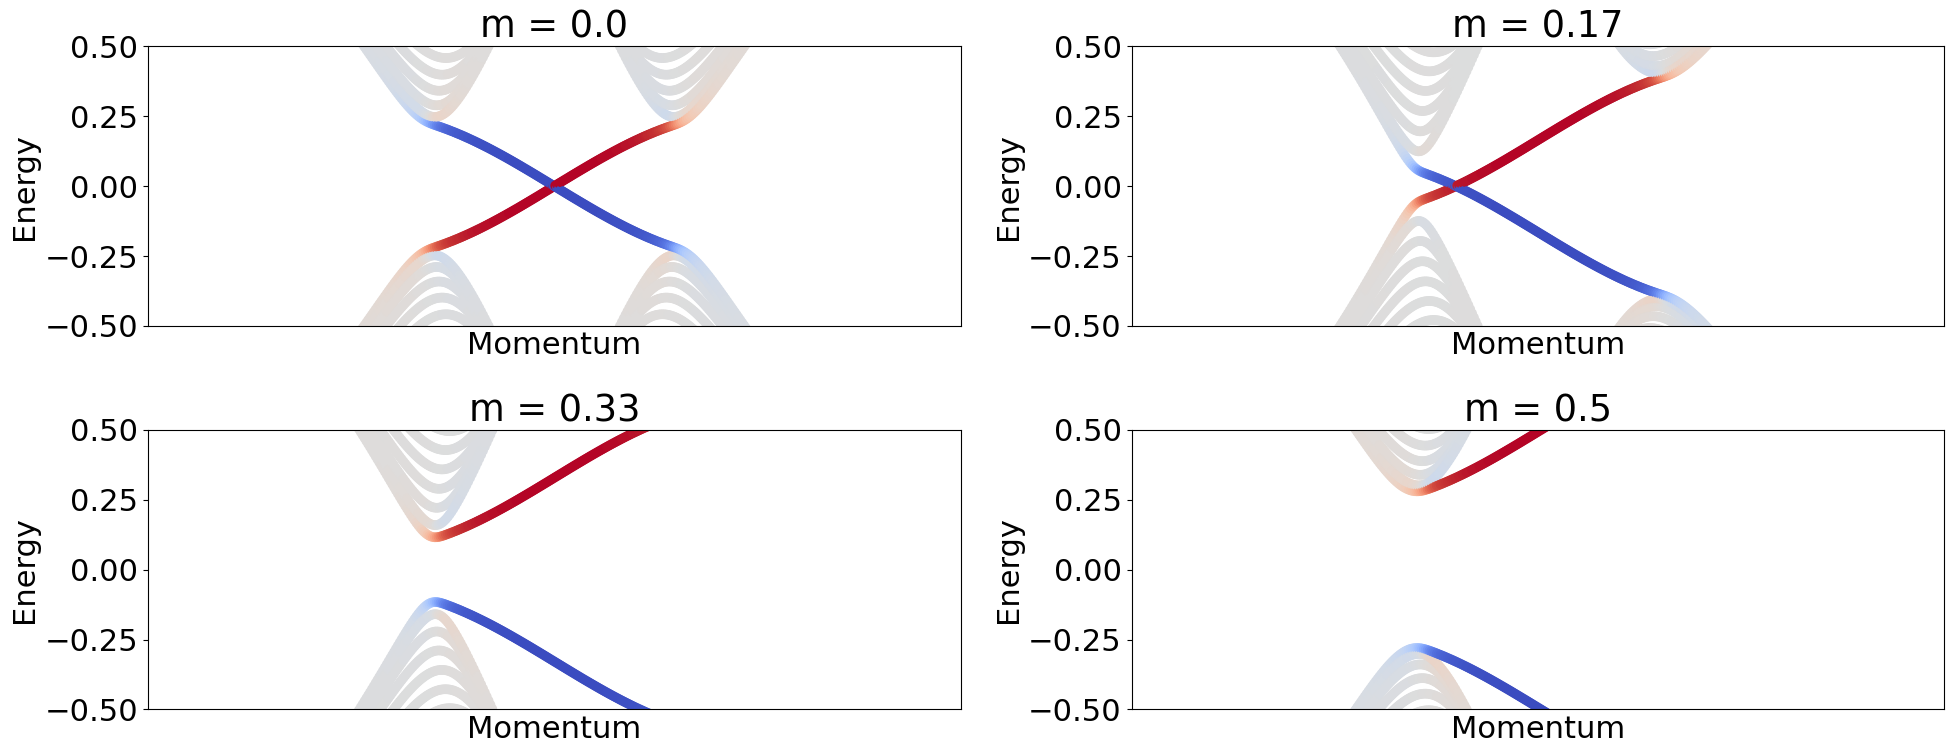

In [11]:
from pyqula import geometry
N = 4 # number of plots
ms = np.linspace(0.,0.5,N) # energies
g = geometry.honeycomb_zigzag_ribbon(20) # honeycomb ribbon with armchair edge, the number controls the width

ii = 1 # counter for the subplots
for m in ms:
    plt.subplot(N//2,2,ii); ii += 1 
    h = g.get_hamiltonian(has_spin=False) # generate the Hamiltonian
    h.add_haldane(0.05) # add Haldane coupling
    h.add_sublattice_imbalance(m) # add a sublattice imbalance
    (k,e,c) = h.get_bands(operator="yposition") # compute band structure
    plt.scatter(k,e,c=c) ; plt.xlabel("Momentum") ; plt.ylabel("Energy") 
    plt.xticks([]) ; plt.ylim([-.5,.5]) # plot
    plt.title("m = "+str(np.round(m,2))) # set the title
plt.tight_layout() # adjust the subplots

### Exercise
- At which value do the gapless edge states disappear?
- How does this value compare with the value for the bulk gap closing?
- Compute how is this very same phenomenology for an armchair ribbon

## Finite size effects in topological systems (***Challenge***)
Let us now consider a topological system, and explore how its electronic structure depends on the wisth of the ribbon. We will generate a Chern insulator by combining exchange coupling and Rashba spin-orbit coupling

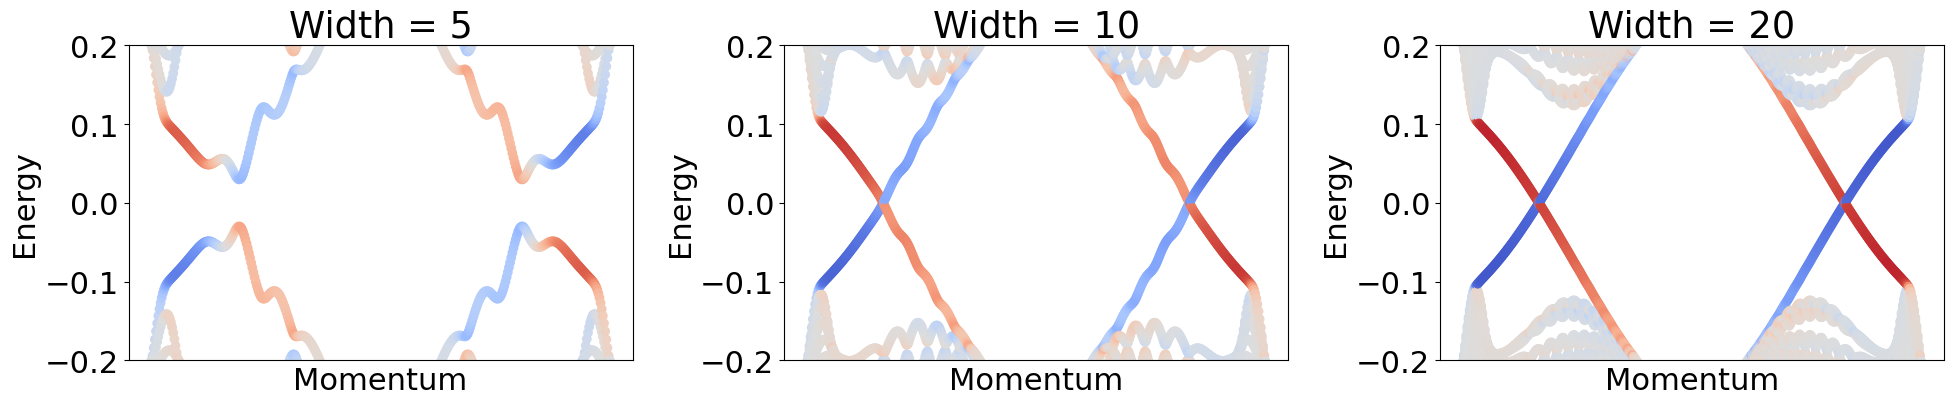

In [12]:
from pyqula import geometry
Ws = [5,10,20] # widths of the ribbons
ii = 1 # counter for the subplots
rashba = 0.1 # strength of Rashba SOC
for W in Ws: # loop over widths
    g = geometry.honeycomb_zigzag_ribbon(W) # honeycomb ribbon with armchair edge, the number controls the width
    plt.subplot(2,len(Ws),ii); ii += 1 
    h = g.get_hamiltonian() # generate the Hamiltonian
    h.add_exchange([0.,0.,0.8]) # add exchange coupling
    h.add_rashba(rashba) # add Rashba SOC
    (k,e,c) = h.get_bands(kpath=["X","G","X"],operator="yposition") # compute band structure
    plt.scatter(k,e,c=c) ; plt.xlabel("Momentum") ; plt.ylabel("Energy") 
    plt.xticks([]) ; plt.ylim([-2*rashba,2*rashba]) # plot
    plt.title("Width = "+str(W)) # set the title
plt.tight_layout() # adjust the subplots

### Exercise
- Why is there a gap in the edge states for narrow ribbons?
- Make the Rashba SOC three times as big. What happens to the edge states?
- What is the energy scale that determines how wide the ribbon should be to have gapless edge states?

## The quantum spin Hall state (***Core***)
Let us now focus on a different topological state of matter, the quantum spin Hall effect. This topological state is driven by spin-orbit coupling and features a pair of states in each edge

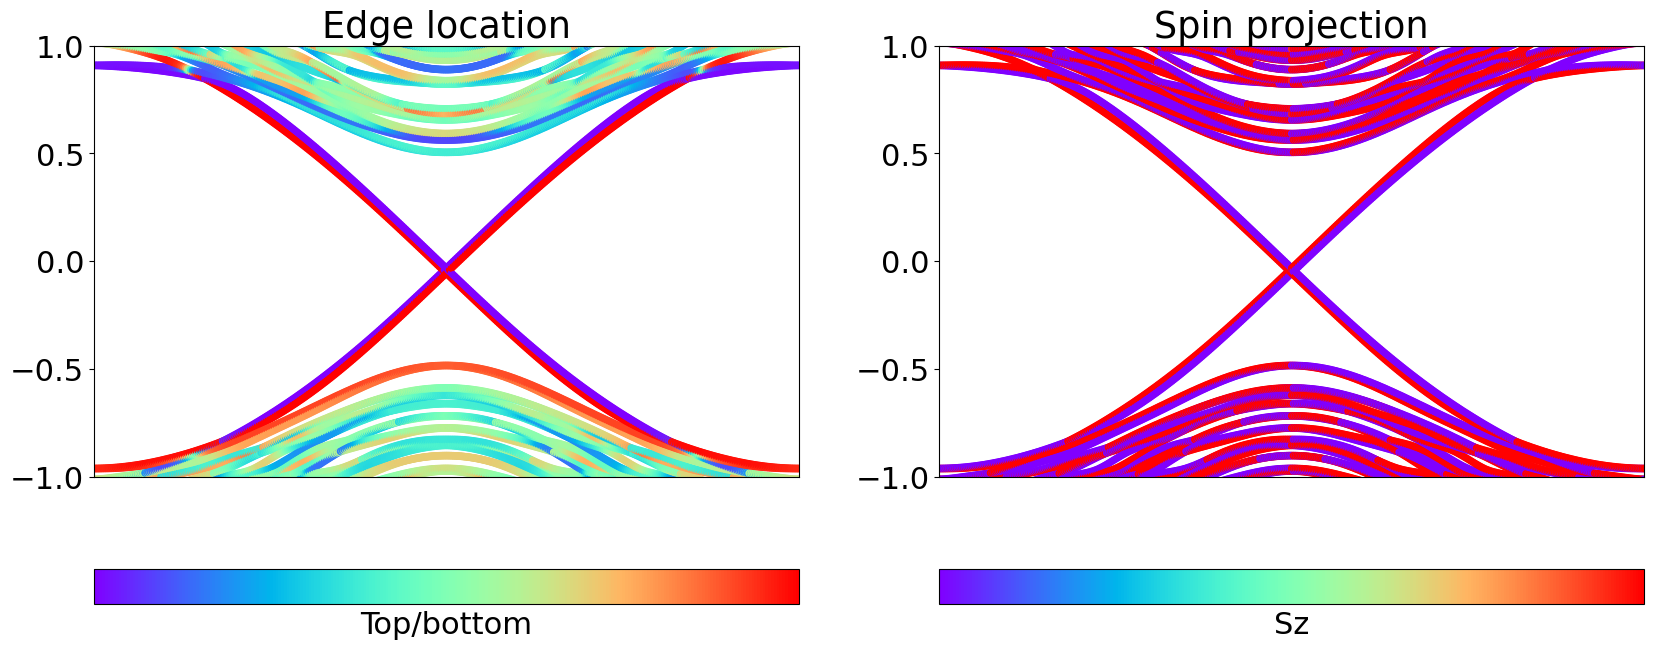

In [13]:
from pyqula import geometry
W = 14 # width of the ribbon
g = geometry.honeycomb_armchair_ribbon(W) # honeycomb ribbon with armchair edge, the number controls the width
h = g.get_hamiltonian() # generate the Hamiltonian
h.add_soc(0.12) # add intrinsic SOC
h.add_onsite(lambda r: 0.6*(np.random.random()-0.5)) # some small disorder to break accidental degeneracies

Ptb = h.get_operator(lambda r: np.sign(r[1])) # projector on the top or bottom part
Sz = h.get_operator("sz") # Sz operator
(ktb,etb,ctb) = h.get_bands(operator=Ptb,kpath=["X","G","X"]) # band projected on the top edge
(ksz,esz,csz) = h.get_bands(operator=Sz,kpath=["X","G","X"]) # band projected in spin

def plot_bands(k,e,c): # function to plot bands
    plt.scatter(k,e,c=c,s=20,cmap="rainbow") ; plt.xlim([min(k),max(k)]) 
    plt.xticks([]) ; plt.ylim([-1.,1.])

# plot projected on the edge
plt.subplot(1,2,1) ; plt.title("Edge location") ; plot_bands(ktb,etb,ctb)
plt.colorbar(label="Top/bottom",ticks=[],orientation="horizontal")

# plot projected ont eh spin
plt.subplot(1,2,2) ; plt.title("Spin projection") ; plot_bands(ksz,esz,csz)
plt.colorbar(label="Sz",ticks=[],orientation="horizontal")


### Quiz
- In whch edge and what is the spin projection of each in gap state?
- The system has disorder and yet the states in the gap do not hybridize, how can that be?
- Make the system narrower, what happens to the in-gap modes and why?

## The robustness of the quantum spin Hall state (***Core***)
Let us now address the robustness of the quantum spin Hall effect. This topological state features edge states that are robust to perturbations that do not break time reversal symmetry

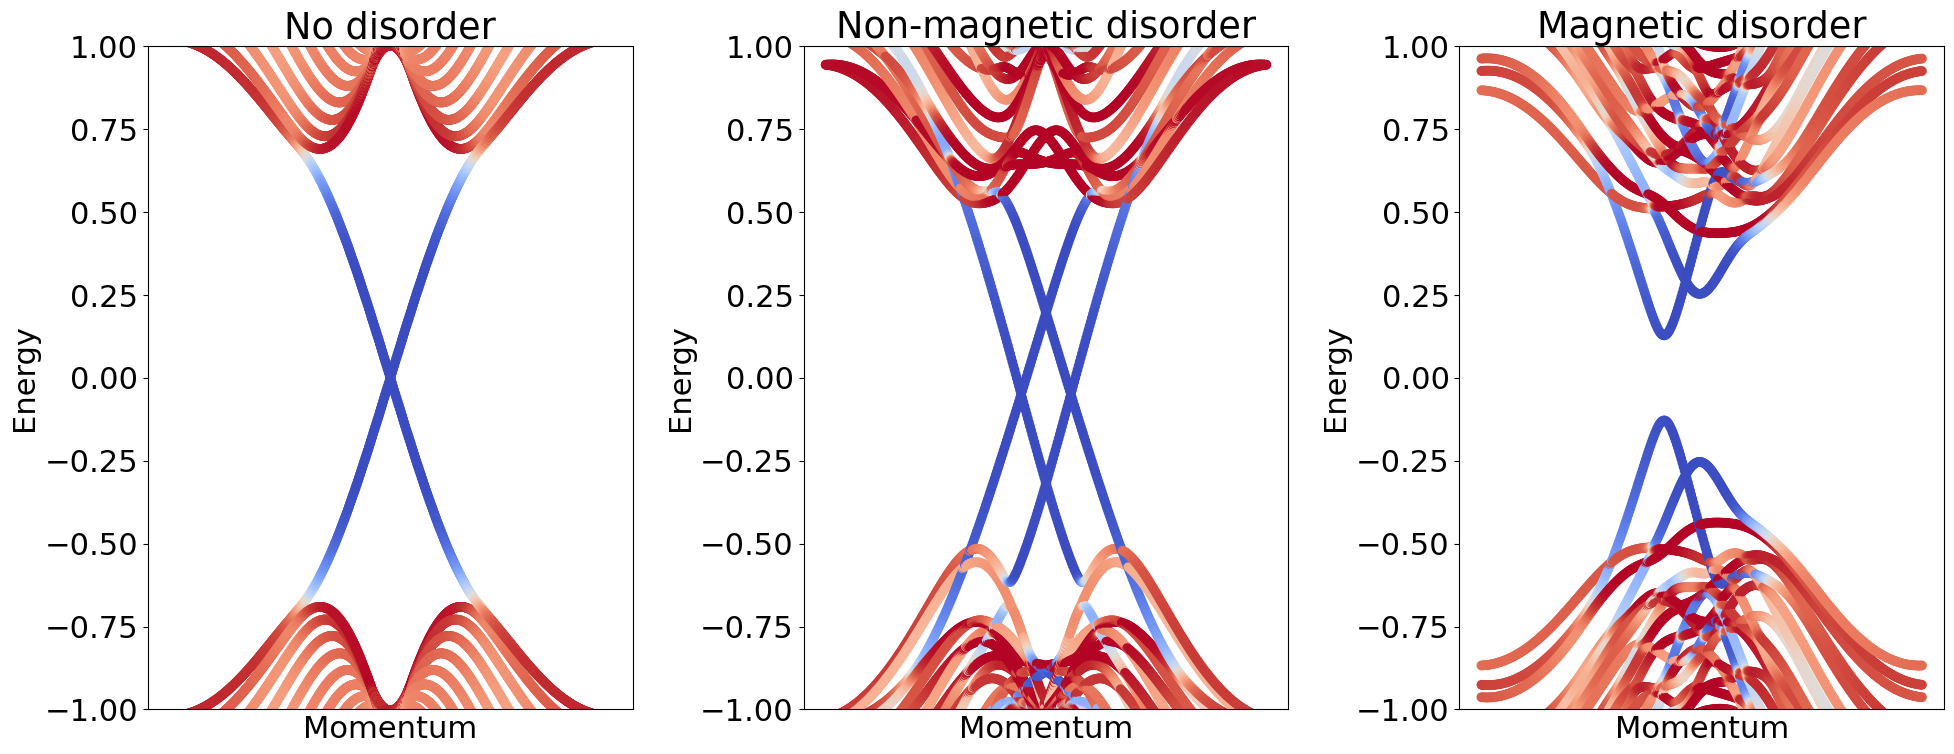

In [14]:
from pyqula import geometry
g = geometry.honeycomb_zigzag_ribbon(10) # honeycomb ribbon with armchair edge, the number controls the width
h = g.get_hamiltonian() # generate the Hamiltonian
h.add_soc(0.15) # add intrinsic SOC

# first, let us consider a ribbon without disorder
plt.subplot(1,3,1) ; plt.title("No disorder")
(k,e,c) = h.get_bands(operator="bulk") # compute band structure
plt.scatter(k,e,c=c) ; plt.xlabel("Momentum") ; plt.ylabel("Energy") ; plt.xticks([]) ; plt.ylim([-1.,1.])

# now, lets add non-magnetic disorder
plt.subplot(1,3,2) ; plt.title("Non-magnetic disorder")
hd = h.copy() ; hd.add_onsite(lambda r: 1.*(np.random.random()-0.5)) # new Hamiltonian with disorder
(k,e,c) = hd.get_bands(operator="bulk") # compute band structure
plt.scatter(k,e,c=c) ; plt.xlabel("Momentum") ; plt.ylabel("Energy") ; plt.xticks([]) ; plt.ylim([-1.,1.])

# now, lets add magnetic disorder
plt.subplot(1,3,3) ; plt.title("Magnetic disorder")
hd = h.copy() ; hd.add_exchange(lambda r: 1.*(np.random.random(3)-0.5)) # new Hamiltonian with disorder
(k,e,c) = hd.get_bands(operator="bulk") # compute band structure
plt.scatter(k,e,c=c) ; plt.xlabel("Momentum") ; plt.ylabel("Energy") ; plt.xticks([]) ; plt.ylim([-1.,1.])

plt.tight_layout() # adjust plots

### Exercise
- Take an armchair ribbon and recompute the previous bandstructure. Do you observe the same phenomenology?
- Take a supercell of the system, and repeat the calculations above. Do you observe the same phenomenology?
- Discuss how this can be rationalized in terms of topological invariants

### In the lab
- Quantum spin Hall effect appears in monolayer 1T-WTe2 up to 100K
https://www.science.org/doi/10.1126/science.aan6003

## Topological invariant of the quantum spin Hall state
Let us now see how the topological invariant of a gapped system with time reversal symmetry allows to predict the existence fo edge states

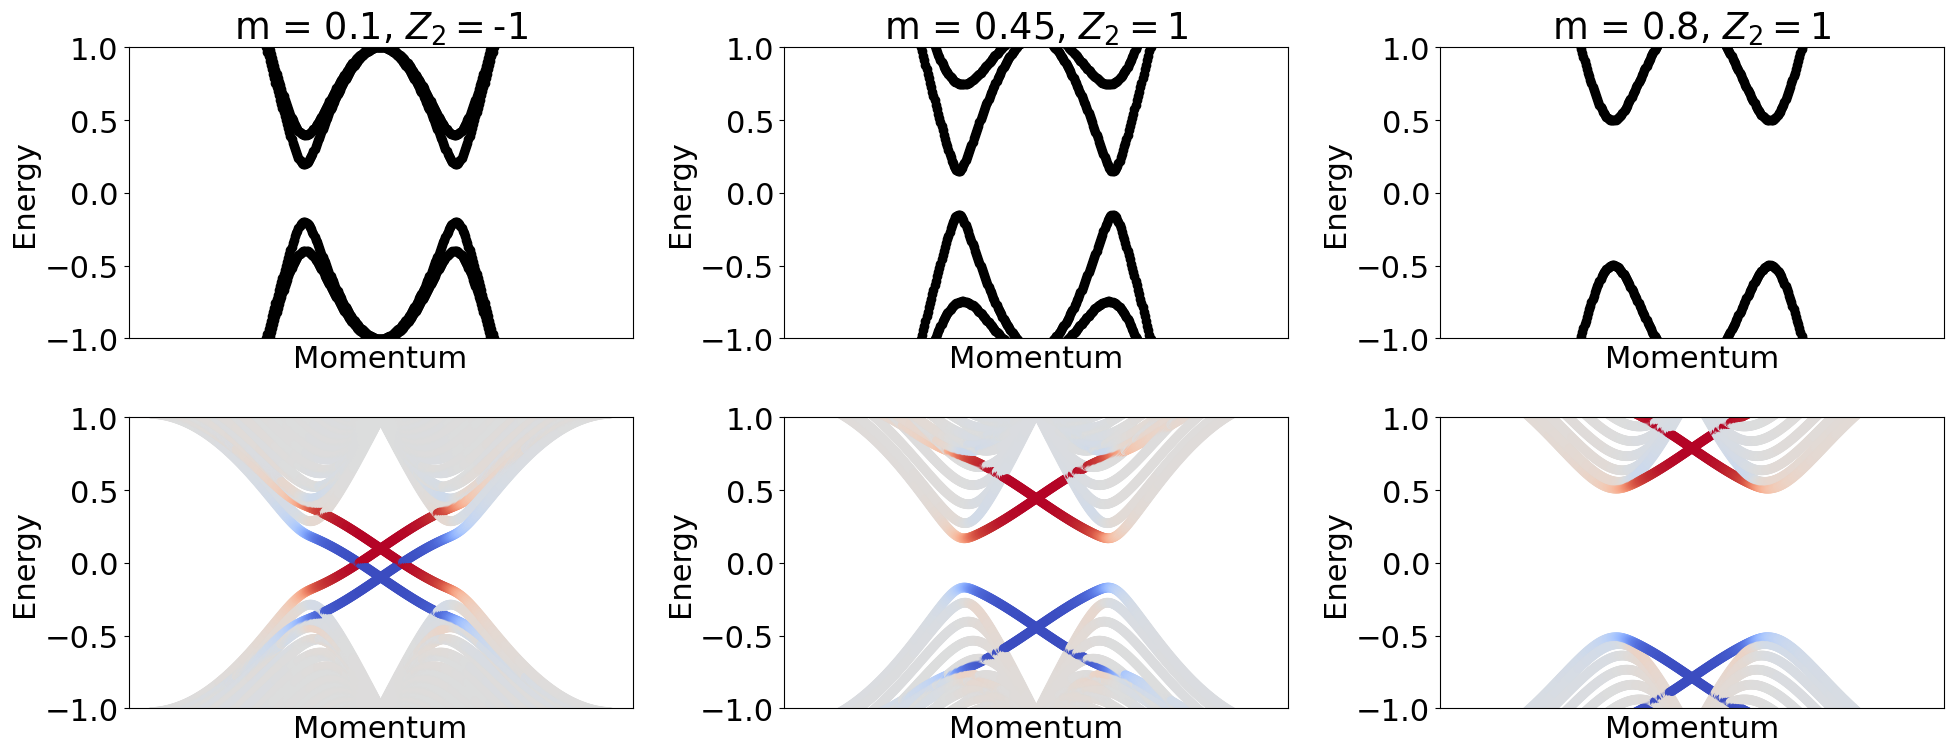

In [15]:
from pyqula import geometry, ribbon, topology
ms = np.linspace(0.1,0.8,3) # number of plots

ii = 1 # counter for the subplots
for m in ms:
    # bulk electronic structure and topological invariant
    plt.subplot(2,len(ms),ii) # new subplot 
    g = geometry.honeycomb_lattice() # honeycomb lattice
    h = g.get_hamiltonian(tij=[1.,0.]) ; h.set_filling(0.5) # generate the Hamiltonian at half filling
    h.add_soc(0.1) # add SOC that drives QSH
    h.add_sublattice_imbalance(m) # add a sublattice imbalance
    (k,e) = h.get_bands() # compute band structure
    plt.scatter(k,e,c="black") ; plt.xlabel("Momentum") ; plt.ylabel("Energy") 
    plt.xticks([]) ; plt.ylim([-1.,1.]) # plot
    z2 = topology.z2_invariant(h) # compute the Z2 invariant
    plt.title("m = "+str(np.round(m,2))+", $Z_2 =$"+str(z2)) # set the title
    # now electronic structure of a ribbon
    plt.subplot(2,len(ms),ii+len(ms)) # new subplot 
    h = ribbon.bulk2ribbon(h,n=20) # create a ribbon
    (k,e,c) = h.get_bands(operator="yposition") # compute band structure
    plt.scatter(k,e,c=c) ; plt.xlabel("Momentum") ; plt.ylabel("Energy") ; plt.xticks([]) ; plt.ylim([-1.,1.])
    ii += 1
plt.tight_layout() # adjust the subplots

### Exercise
- Count how many helical states you have in each edge for the 1D system for each case
- Add Rashba spin-orbit coupling (add_rashba). Do you still see the edge states? Discuss why
- Add a second neighbor hopping (g.get_hamitlonian(tij=[1.,0.2]). Do you still see the edge states? Discuss why


## The valley Hall effect (***Challenge***)

Let us now address how an electrically controllable topological edge state can appear in graphene multilayers


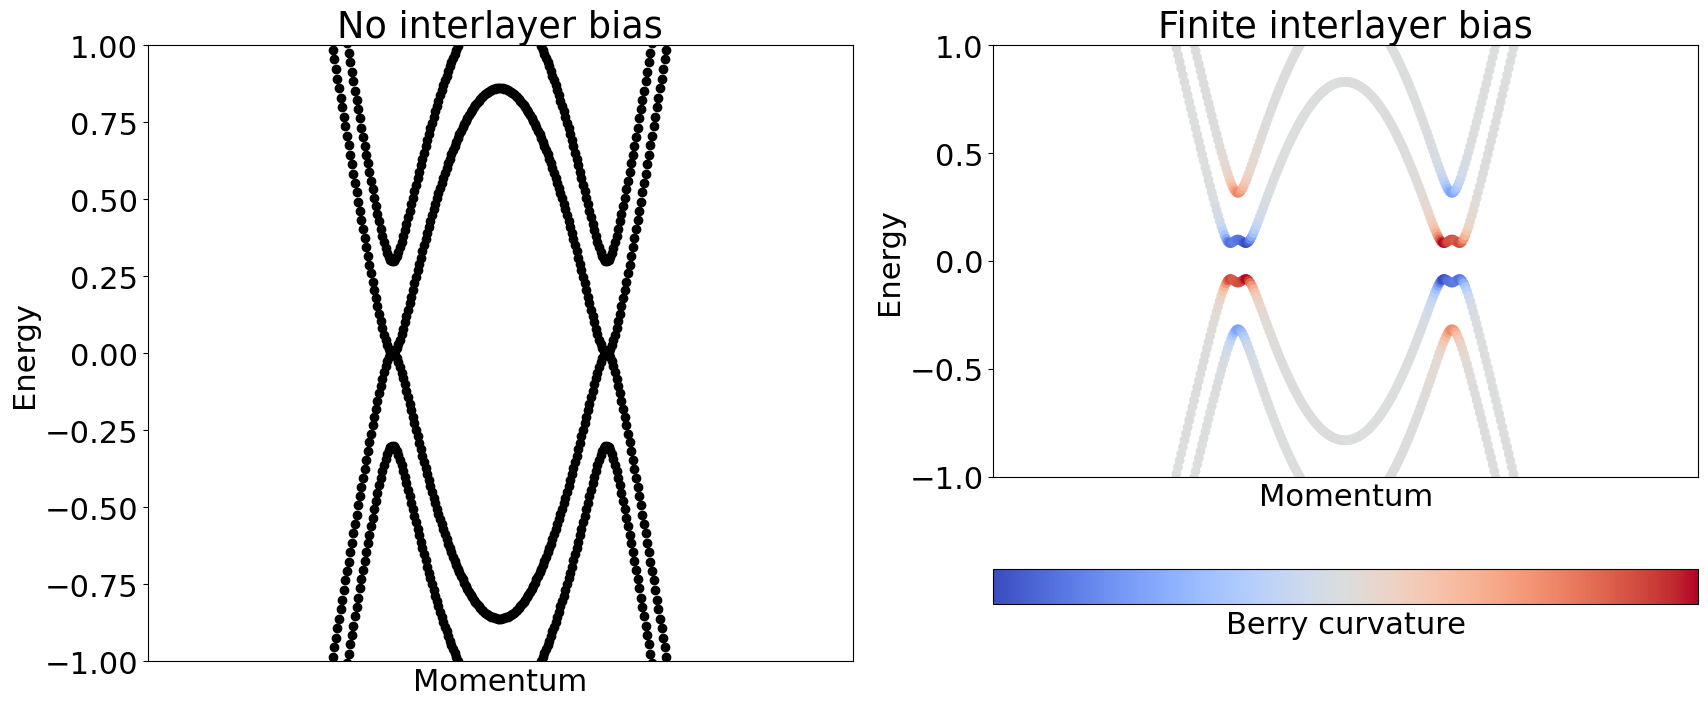

In [16]:
from pyqula import specialhamiltonian # use 
h = specialhamiltonian.multilayer_graphene(l=[0,1],ti=0.3) # Hamiltonian of an AB bilayer 

# first without an interlayer bias
plt.subplot(1,2,1) ; plt.title("No interlayer bias")
(k,e) = h.get_bands() # compute band structure
plt.scatter(k,e,c="black") ; plt.xlabel("Momentum") ; plt.ylabel("Energy") ; plt.xticks([]) ; plt.ylim([-1.,1.])


# now with an interlayer bias
plt.subplot(1,2,2) ; plt.title("Finite interlayer bias")
h.add_onsite(lambda r: 0.1*np.sign(r[2])) # bias difference between layers
(k,e,c) = h.get_bands(operator="berry") # compute band structure
plt.scatter(k,e,c=c) ; plt.xlabel("Momentum") ; plt.ylabel("Energy") ; plt.xticks([]) ; plt.ylim([-1.,1.]) # plot
plt.colorbar(label="Berry curvature",ticks=[],orientation="horizontal")

(-0.5, 0.5)

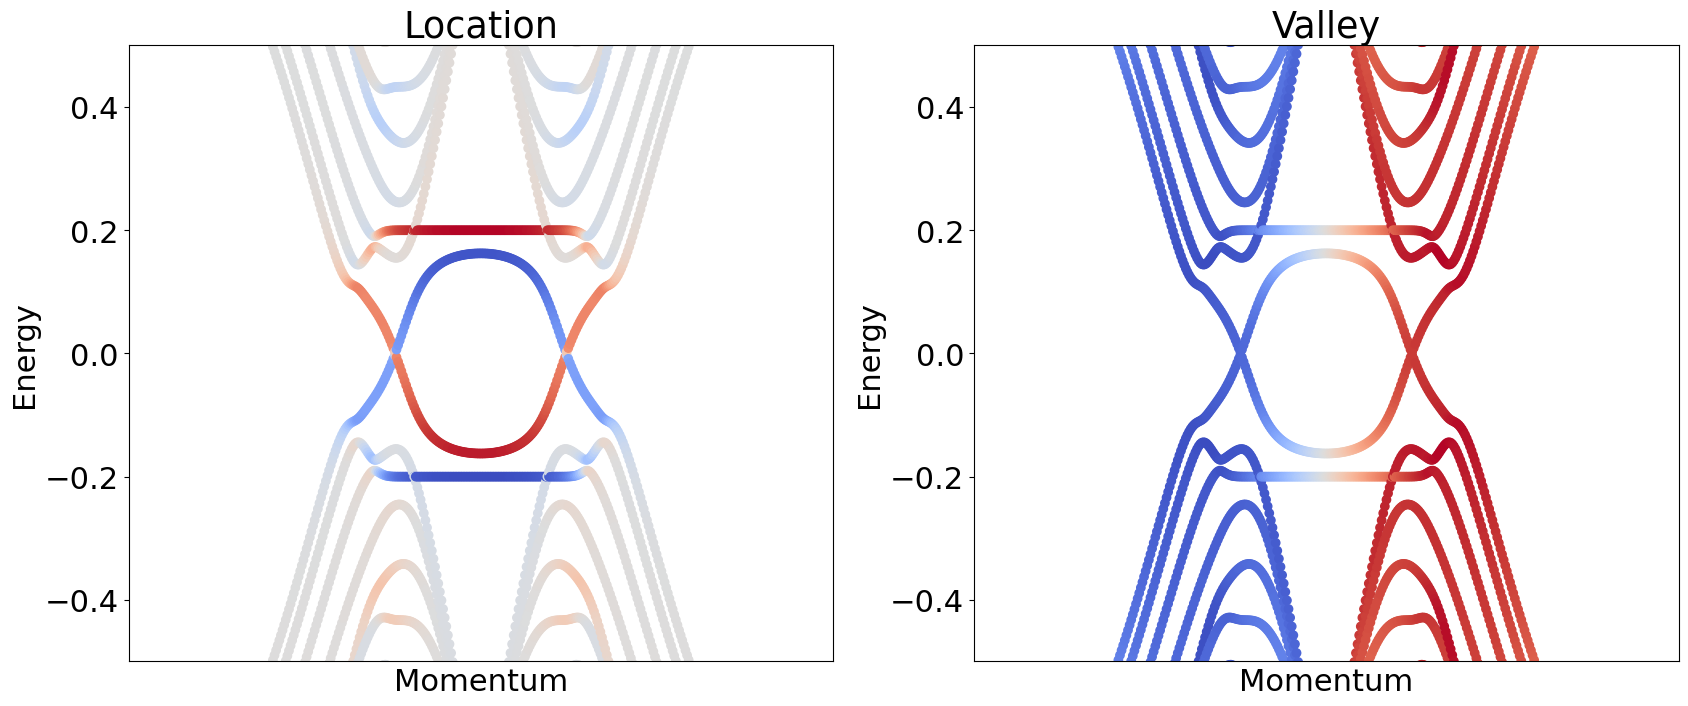

In [17]:
# let us now compute a ribbon of bilayer AB graphene
from pyqula import specialhamiltonian # use 
h = specialhamiltonian.multilayer_graphene(l=[0,1],ti=0.3) # Hamiltonian of an AB bilayer 
from pyqula import ribbon
h = ribbon.bulk2ribbon(h,n=20) # generate a ribbon from the bulk Hamiltonian
h.add_onsite(lambda r: 0.2*np.sign(r[2])) # bias difference between layers

# compute the expectation value of the location
plt.subplot(1,2,1) ; plt.title("Location")
(k,e,c) = h.get_bands(operator="yposition") # compute band structure
plt.scatter(k,e,c=c) ; plt.xlabel("Momentum") ; plt.ylabel("Energy") ; plt.xticks([]) ; plt.ylim([-.5,.5])# plot

# compute the expectation value of the valley
plt.subplot(1,2,2) ; plt.title("Valley")
(k,e,c) = h.get_bands(operator="valley") # compute band structure
plt.scatter(k,e,c=c) ; plt.xlabel("Momentum") ; plt.ylabel("Energy") ; plt.xticks([]) ; plt.ylim([-.5,.5])# plot



### Quiz
- Discuss what is the direction of the propagation, valley quantum number, and location of each state
- Create a ribbon where in the upper half there is a positive interlayer bias, and in the lower half a negative interlayer bias. How many states do you observe?